In [124]:
import pandas as pd
import matplotlib.pyplot as plt

In [151]:
# lets see if theres any correllation between rainfall and water Level
weather_df = pd.read_csv("valid_data/weather.csv")
hydro_df = pd.read_csv("valid_data/hydrometric.csv")

In [152]:
hydro_df

,Date,Station ID,Station Name,Province,Latitude,Longitude,Daily Discharge,SYM1,Daily Water Level,SYM2,match key
0,2013-01-01,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,23.2,NaN,20.153,NaN,4
1,2013-01-02,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.3,NaN,20.126,NaN,4
2,2013-01-03,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,20.9,NaN,20.120,NaN,4
3,2013-01-04,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.0,NaN,20.122,NaN,4
4,2013-01-05,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.8,NaN,20.133,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...
32131,2023-12-27,08NH118,DUNCAN RIVER BELOW LARDEAU RIVER,BC,50.23286,-116.95519,160.0,NaN,2.201,NaN,2
32132,2023-12-28,08NH118,DUNCAN RIVER BELOW LARDEAU RIVER,BC,50.23286,-116.95519,161.0,NaN,2.205,NaN,2
32133,2023-12-29,08NH118,DUNCAN RIVER BELOW LARDEAU RIVER,BC,50.23286,-116.95519,160.0,NaN,2.204,NaN,2
32134,2023-12-30,08NH118,DUNCAN RIVER BELOW LARDEAU RIVER,BC,50.23286,-116.95519,160.0,NaN,2.201,NaN,2


In [153]:
weather_df.head()

,Station Name,Latitude,Longitude,Date,MIN_TEMPERATURE,MAX_TEMPERATURE,MEAN_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,match key
0,CAMPBELL RIVER A,49.951944,-125.273056,2013-01-01,1.2,3.1,2.2,0.0,0.0,0.0,3.0,3
1,CAMPBELL RIVER A,49.951944,-125.273056,2013-01-02,0.0,3.4,1.7,0.0,0.0,0.0,3.0,3
2,CAMPBELL RIVER A,49.951944,-125.273056,2013-01-03,0.8,2.7,1.8,1.6,1.6,0.0,0.0,3
3,CAMPBELL RIVER A,49.951944,-125.273056,2013-01-04,1.3,5.2,3.3,6.8,6.8,0.0,0.0,3
4,CAMPBELL RIVER A,49.951944,-125.273056,2013-01-05,1.3,5.8,3.6,7.4,7.4,0.0,0.0,3


In [154]:
hydro_df.head()

,Date,Station ID,Station Name,Province,Latitude,Longitude,Daily Discharge,SYM1,Daily Water Level,SYM2,match key
0,2013-01-01,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,23.2,NaN,20.153,NaN,4
1,2013-01-02,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.3,NaN,20.126,NaN,4
2,2013-01-03,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,20.9,NaN,20.120,NaN,4
3,2013-01-04,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.0,NaN,20.122,NaN,4
4,2013-01-05,08HB006,PUNTLEDGE RIVER AT COURTENAY,BC,49.68803,-125.03419,21.8,NaN,20.133,NaN,4


In [155]:
# get the subset we're interested in doing analysis on (in this case total rain and water level)
rain_data = weather_df[["Date","TOTAL_RAIN","match key"]]
level_data = hydro_df[["Date","Daily Water Level","match key"]]

In [181]:
# get the data for a single matched station
rain_data_0 = rain_data[rain_data["match key"] == 7]
level_data_0 = level_data[level_data["match key"] == 7]

In [182]:
rain_data_0["Date"]

5121    2013-01-01
5122    2013-01-02
5123    2013-01-03
5124    2013-01-04
5125    2013-01-05
           ...    
6566    2023-12-24
6567    2023-12-25
6568    2023-12-26
6569    2023-12-29
6570    2023-12-31
Name: Date, Length: 1450, dtype: object

In [183]:
level_data_0["Date"]

4017    2013-01-01
4018    2013-01-02
4019    2013-01-03
4020    2013-01-04
4021    2013-01-05
           ...    
8029    2023-12-27
8030    2023-12-28
8031    2023-12-29
8032    2023-12-30
8033    2023-12-31
Name: Date, Length: 4017, dtype: object

In [132]:
combine0 = rain_data_0.merge(level_data_0, on="Date")

In [133]:
combine0

,Date,TOTAL_RAIN,match key_x,Daily Water Level,match key_y


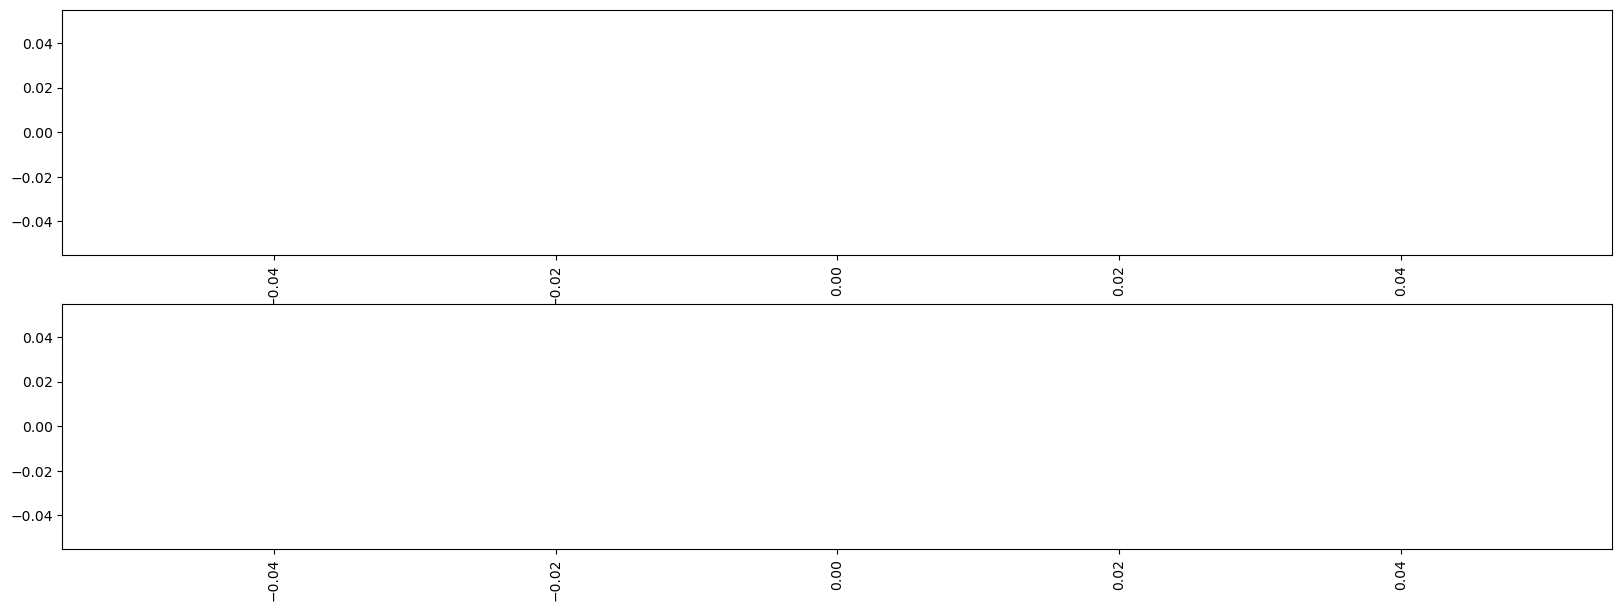

In [134]:
fig, axs = plt.subplots(2, figsize=(20,7))
x = 365
axs[0].plot(combine0["Date"][:x], combine0["TOTAL_RAIN"][:x])
axs[0].tick_params('x', labelrotation=90)
axs[1].plot(combine0["Date"][:x], combine0["Daily Water Level"][:x], color="orange")
axs[1].tick_params('x', labelrotation=90)
plt.show()

In [135]:
ml_data = combine0[['Date','TOTAL_RAIN', 'Daily Water Level']]

In [136]:
ml_data["y"] = ml_data["Daily Water Level"].shift(-1)

In [137]:
ml_data

,Date,TOTAL_RAIN,Daily Water Level,y


In [138]:
ml_data.iloc[:-1]

,Date,TOTAL_RAIN,Daily Water Level,y


In [140]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
model = make_pipeline(
    MinMaxScaler(),
    MLPClassifier(solver='lbfgs', hidden_layer_sizes=(4,3), activation='logistic')
)
ml_data = ml_data.iloc[:-1]
print(len(ml_data))
X = ml_data[["Daily Water Level", "TOTAL_RAIN"]]
y = ml_data["y"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y)
X_train
# model.fit(X_train, y_train)
# print(model.score(X_valid, y_valid))

0


ValueError: With n_samples=0, test_size=0.25 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.